## Face detection using OpenCV

One older (from around 2001), but still popular scheme for face detection is a Haar cascade classifier; these classifiers in the OpenCV library and use feature-based classification cascades that learn to isolate and detect faces in an image. You can read [the original paper proposing this approach here](https://www.cs.cmu.edu/~efros/courses/LBMV07/Papers/viola-cvpr-01.pdf).

Let's see how face detection works on an exampe in this notebook.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


%matplotlib inline

In [2]:
IMG = '../../../img'

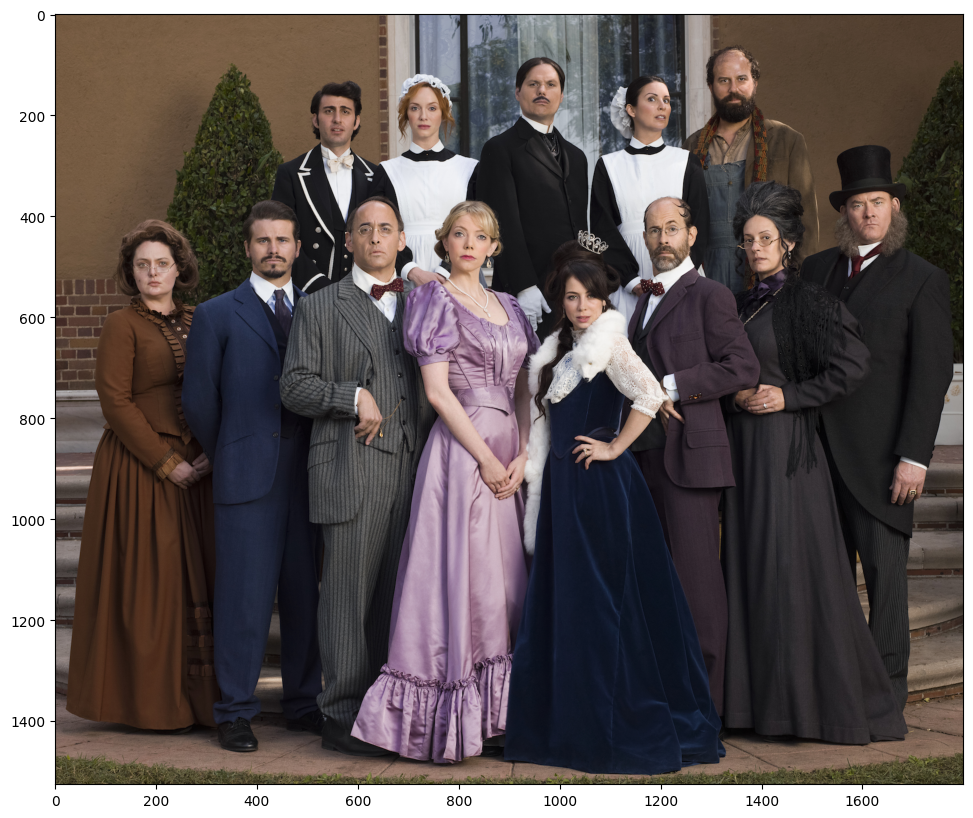

In [5]:
image = cv2.imread(f'{IMG}/multi_faces.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20, 10))
plt.imshow(image);

To use a face detector, we'll first convert the image from color to grayscale.  For face detection this is perfectly fine to do as there is plenty non-color specific structure in the human face for our detector to learn on.

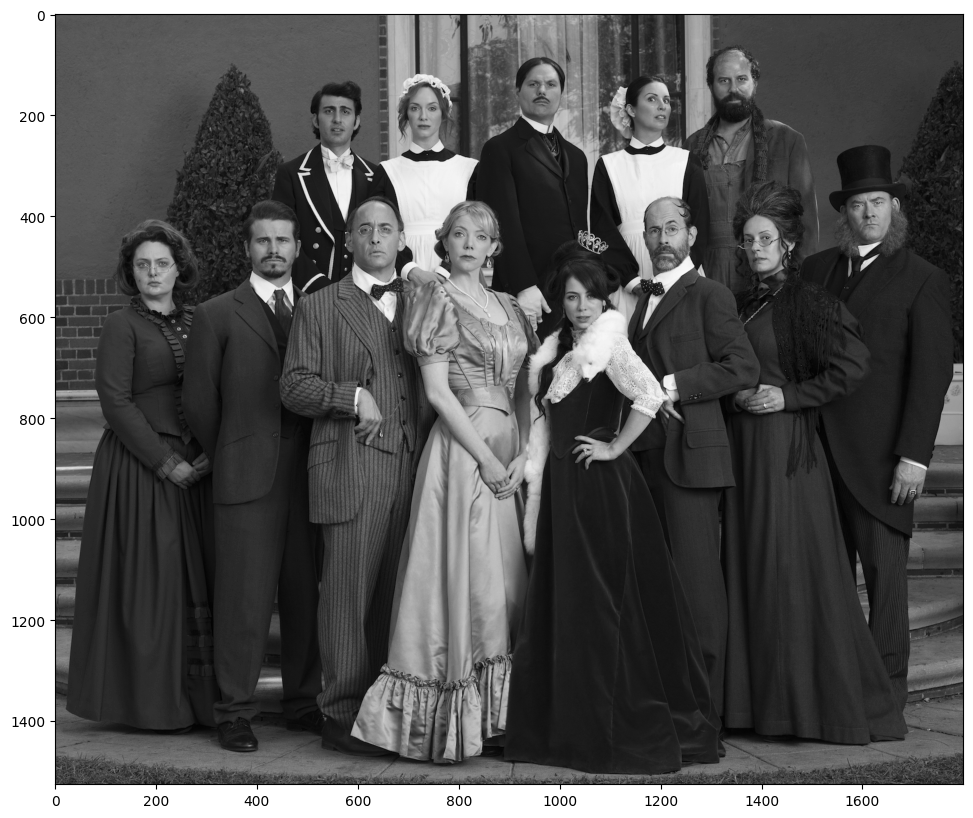

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  
plt.figure(figsize=(20, 10))
plt.imshow(gray, cmap='gray');

Next we load in the fully trained architecture of the face detector, found in the file `detector_architectures/ haarcascade_frontalface_default.xml`,and use it on our image to find faces!

**A note on parameters** 

How many faces are detected is determined by the function, `detectMultiScale` which aims to detect faces of varying sizes. The inputs to this function are: `(image, scaleFactor, minNeighbors)`; you will often detect more faces with a smaller scaleFactor, and lower value for minNeighbors, but raising these values often produces better matches. Modify these values depending on your input image.

In [7]:
face_cascade = cv2.CascadeClassifier(
    'detector_architectures/haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 4, 6)

The output of the classifier is an array of detections; coordinates that define the dimensions of a bounding box around each face. Note that this always outputs a bounding box that is square in dimension.

In [8]:
# print out the detections found
print(f'Found {len(faces)} faces in this image')
print("Coordinates and lengths/widths:")
print('=============================')
print(faces)

Found 13 faces in this image
Coordinates and lengths/widths:
[[1295   94   96   96]
 [ 917  102   96   96]
 [1565  339   96   96]
 [ 683  149   96   96]
 [1148  131   96   96]
 [ 510  158   96   96]
 [ 588  390   96   96]
 [1157  391   96   96]
 [ 771  405   96   96]
 [ 383  414   96   96]
 [1345  411   96   96]
 [ 146  458   96   96]
 [ 996  526   96   96]]


Let's plot the corresponding detection boxes on our original image to see how well we've done.  

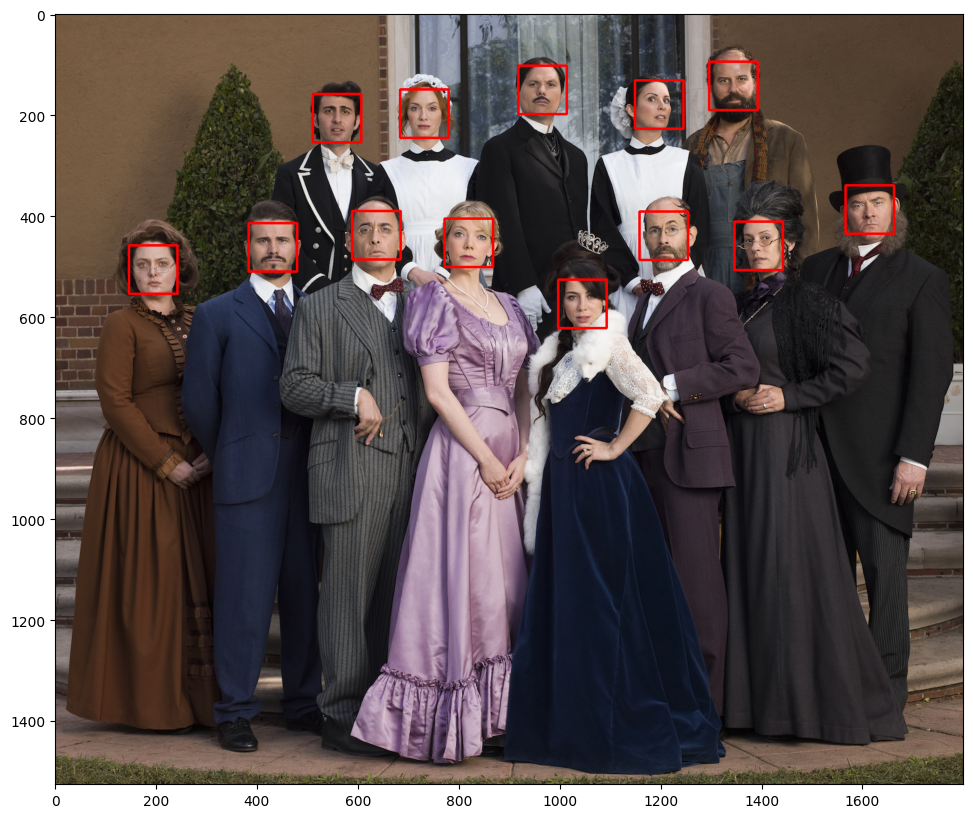

In [9]:
img_with_detections = np.copy(image)
for (x, y, w, h) in faces:
    cv2.rectangle(img_with_detections, (x, y), (x + w, y + h), (255, 0, 0), 3)  
plt.figure(figsize=(20, 10))
plt.imshow(img_with_detections);